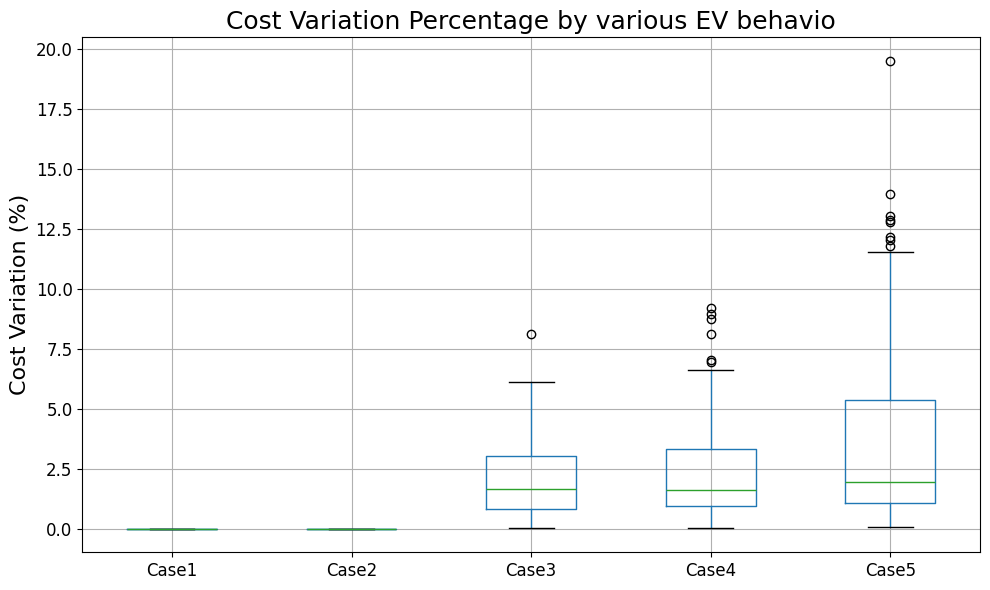

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

# すべてのCSVファイルのパスを取得（ファイル名がSummary_EV5_0〜9と仮定）
file_paths = glob.glob('Summary_EV5_*.csv')

# 各ファイルを読み込んでリストに格納
dfs = []
for path in file_paths:
    df = pd.read_csv(path)
    df['SourceFile'] = path  # どのファイルから来たか記録
    dfs.append(df)

# 全部結合
combined_df = pd.concat(dfs, ignore_index=True)

# Scinario 1, 2, 4, 5, 6 のみをフィルタリング
filtered_df = combined_df[combined_df['Scinario'].isin([1, 2, 4, 5, 6])]

# nameとScinarioごとのCostの平均を計算
mean_by_name_scenario = filtered_df.groupby(['name', 'Scinario'])['Cost'].mean()

# nameとScinarioごとにSourceFileごとのCostの標準偏差を計算
std_by_name_scenario_file = filtered_df.groupby(['name', 'Scinario'])['Cost'].std()

scenario_label_map = {
    1: 'Case1',
    2: 'Case2',
    3: 'Case3.1',
    4: 'Case3',
    5: 'Case4',
    6: 'Case5'
}

# nameとScinarioごとのCostの平均値を基に、標準偏差をその平均で割ってパーセント表示
percent_variation = (std_by_name_scenario_file / mean_by_name_scenario) * 100



# 結果をボックスプロットで表示
fig, ax = plt.subplots(figsize=(10, 6))

# ボックスプロットを描画
percent_variation=percent_variation.unstack()

percent_variation=percent_variation.rename(columns=scenario_label_map)

percent_variation.boxplot(ax=ax)

# タイトルとラベルのフォントサイズを設定
plt.title('Cost Variation Percentage by various EV behavio', fontsize=18)  # タイトルの文字サイズ
plt.xlabel('', fontsize=14)  # X軸の文字サイズ（空白に設定）
plt.ylabel('Cost Variation (%)', fontsize=16)  # Y軸の文字サイズ

# 軸の目盛り（数字）の文字サイズを調整
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 軸の目盛りのサイズを調整
ax.tick_params(axis='both', which='major', labelsize=12)

# グラフの表示
plt.tight_layout()
plt.show()


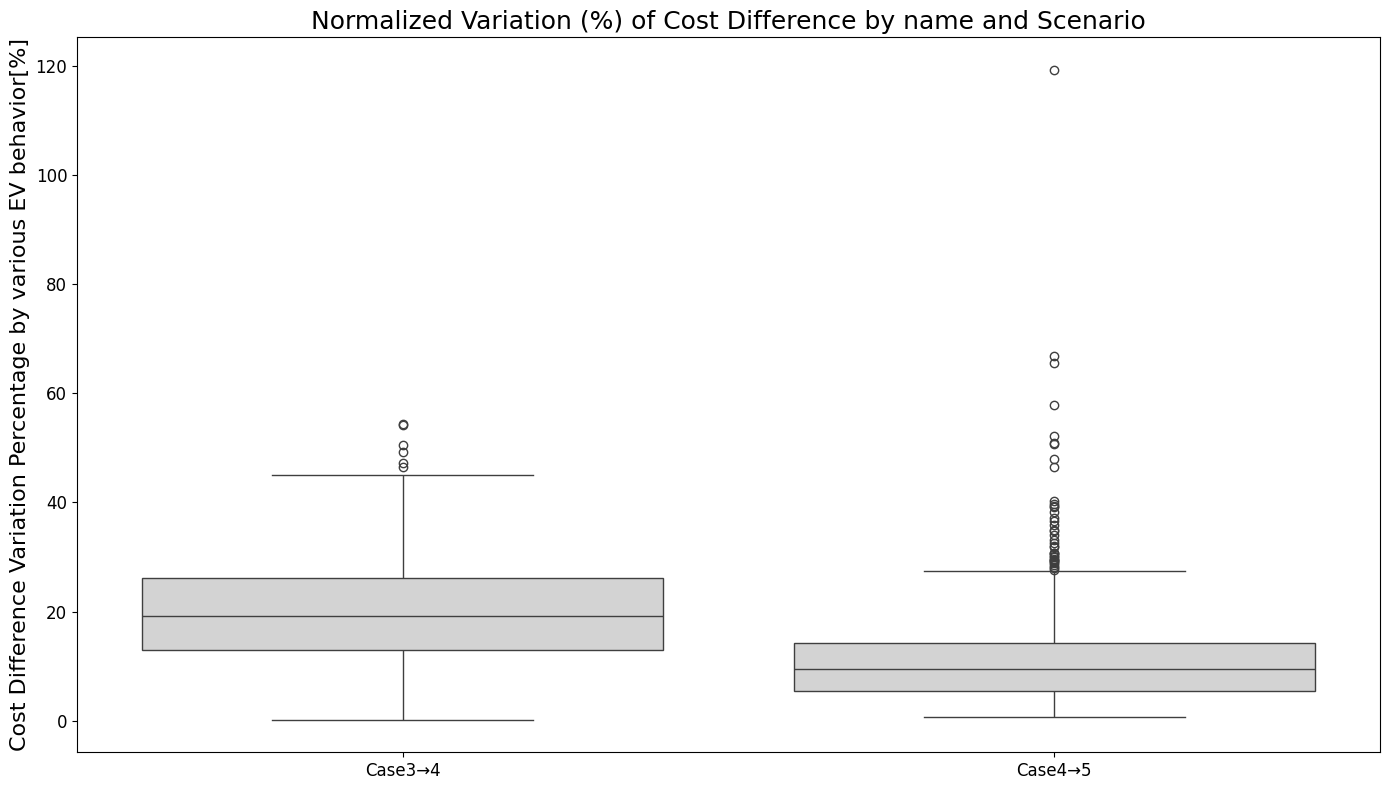

In [53]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# CSVファイルを読み込み
file_paths = glob.glob('Summary_EV5_*.csv')
diff_records = []

for path in file_paths:
    df = pd.read_csv(path)
    df['SourceFile'] = path
    
    # nameごとにScinarioをソートしてCost差分を計算
    df = df.sort_values(by=['name', 'Scinario'])
    df['Cost_diff'] = df.groupby('name')['Cost'].diff()
    
    # 差分がある行だけ抽出
    diff_data = df.dropna(subset=['Cost_diff'])[['name', 'Scinario', 'Cost_diff', 'SourceFile','Cost',]]
    diff_records.append(diff_data)

# 結合
diff_df = pd.concat(diff_records, ignore_index=True)

# Scinario 1,2,4,5,6 のみ対象
diff_df = diff_df[diff_df['Scinario'].isin([5, 6])]

# 🔹 各name × Scinario ごとの平均と標準偏差
mean_by_name_scenario = -diff_df.groupby(['name', 'Scinario'])['Cost_diff'].mean().unstack()
std_by_name_scenario = diff_df.groupby(['name', 'Scinario'])['Cost_diff'].std().unstack()

# 🔹 正規化：標準偏差 ÷ 平均 × 100（％）
variation_percent = (std_by_name_scenario / mean_by_name_scenario) * 100

# 🔁 Scinarioを CaseX→Y 表記にマッピング
scenario_label_map = {
    2: 'Case1→2',
    3: 'Case2→3',
    4: 'Case2→3',
    5: 'Case3→4',
    6: 'Case4→5'
}

# Scinario（列）名を置き換え（注意：3はdiffには無いので除外されるかも）
variation_percent = variation_percent.rename(columns=scenario_label_map)


# 📈 Heatmapで可視化
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=variation_percent,
    color='lightgray'  # ← ここで色をシンプルに指定
)
# タイトルとラベルのフォントサイズを設定
plt.title('Normalized Variation (%) of Cost Difference by name and Scenario', fontsize=18)  # タイトルの文字サイズ
plt.xlabel('', fontsize=14)  # X軸の文字サイズ（空白に設定）
plt.ylabel('Cost Difference Variation Percentage by various EV behavior[%]', fontsize=16)  # Y軸の文字サイズ

# 軸の目盛り（数字）の文字サイズを調整
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# グラフのレイアウトを調整して表示
plt.tight_layout()
plt.show()




In [ ]:
# 結果格納
violation_counts = []

# 各ファイルごとに処理
for path in file_paths:
    df = pd.read_csv(path)
    df = df[df['Scinario'].isin([1, 2, 3, 4, 5, 6])]  # 必要なシナリオに限定
    df = df.sort_values(by=['name', 'Scinario'])
    
    # nameごとに処理
    for name, group in df.groupby('name'):
        costs = group.set_index('Scinario')['Cost'].sort_index()
        diffs = costs.diff().dropna()

        # 順序が崩れている（前より後が小さい = 差分がマイナス）ケースの数
        violations = (diffs < 0).sum()
        
        violation_counts.append({
            'SourceFile': path,
            'name': name,
            'ViolationCount': violations
        })

# データフレーム化
violation_df = pd.DataFrame(violation_counts)

# 👀 どのnameで何回「シナリオ順が崩れたか」を確認
violation_summary = violation_df.groupby('name')['ViolationCount'].sum().sort_values(ascending=False)

# 表示
print(violation_summary.head(10))mean_by_name_scenario


name
B11000005    40
B11000961    40
B11000976    40
B11000975    40
B11000436    40
B11000971    40
B11000969    40
B11000968    40
B11000967    40
B11000966    40
Name: ViolationCount, dtype: int64


<Axes: >

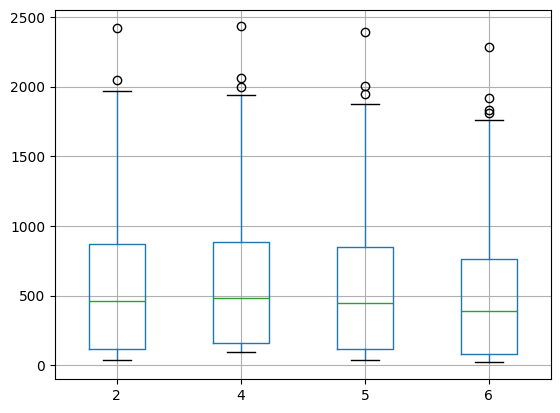

In [43]:
mean_by_name_scenario.boxplot()

<Axes: >

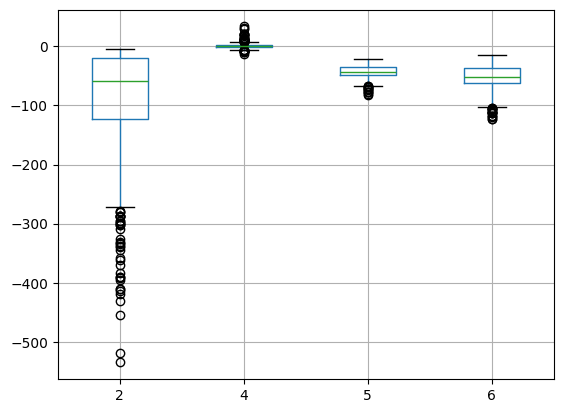

In [44]:
diff_df.groupby(['name', 'Scinario'])['Cost_diff'].mean().unstack().boxplot()

In [45]:
diff_df.groupby(['name', 'Scinario'])['Cost_diff'].mean().unstack()

Scinario,2,4,5,6
name,,,,
B11000005,-199.383557,-0.822567,-39.949076,-50.869053
B11000008,-300.219239,0.170255,-36.733033,-51.439045
B11000010,-344.046069,-0.935452,-33.882635,-55.632295
B11000012,-48.256509,-4.172893,-36.204373,-123.650062
B11000021,-166.563199,-0.062062,-28.871880,-90.294966
...,...,...,...,...
B11001134,-61.559543,-1.723470,-31.381096,-62.647900
B11001135,-149.903314,-3.089374,-44.778044,-105.926697
B11001136,-62.368348,-1.550309,-27.704341,-42.568943


In [46]:
diff_df.groupby(['name', 'Scinario'])['Cost_diff'].std().unstack()

Scinario,2,4,5,6
name,,,,
B11000005,0.0,0.192777,6.566291,2.504055
B11000008,0.0,2.548517,8.399013,3.684891
B11000010,0.0,0.358758,9.227636,5.350741
B11000012,0.0,8.578570,9.667592,14.510388
B11000021,0.0,9.852764,5.666742,14.259808
...,...,...,...,...
B11001134,0.0,9.525399,13.998219,12.842603
B11001135,0.0,35.032409,20.159460,49.323152
B11001136,0.0,11.626350,5.871740,12.150549
